# Consumer Buying Behaviour Survey — Analysis
### Sri Lakshmi Store, Salem | Sona School of Business and Management
**Author:** Srikar S | **Data:** Survey Responses (N=109) | **Year:** 2025–26

## Step 1 — Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import chi2_contingency
import warnings, re
warnings.filterwarnings('ignore')

df = pd.read_csv('survey_100_responses_fixed.csv')
df.columns = [c.strip() for c in df.columns]
print(f'✅ Data loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nFirst 3 rows:')
df.head(3)

✅ Data loaded: 109 rows × 30 columns

First 3 rows:


,Timestamp,Q1. What is your gender?,Q2. What is your age group?,Q3. What is your monthly household income?,Q4. What is your occupation?,Q5. How far do you live from Sri Lakshmi Store?,Q6. How often do you visit Sri Lakshmi Store?,Q7. What is your average spending per visit?,Q8. Which day do you prefer to shop?,Q9. What time of day do you usually shop?,...,Q20. How do you feel about the pricing at Sri Lakshmi Store?,Q21. How satisfied are you with Sri Lakshmi Store overall?,Q22. Rate the following on a scale of 1–5: [Product availability],Q22. Rate the following on a scale of 1–5: [Product quality],Q22. Rate the following on a scale of 1–5: [Pricing],Q22. Rate the following on a scale of 1–5: [Store cleanliness],Q22. Rate the following on a scale of 1–5: [Staff behaviour],Q23. Would you recommend Sri Lakshmi Store to others?,Q24. What is the main reason you choose Sri Lakshmi Store?,Q25. Any suggestions to improve Sri Lakshmi Store?
0,2026/03/20 6:59:17 pm GMT+5:30,Male,20 – 30 years,"₹10,000 – ₹25,000",Student,3 – 5 km,Once in 2 weeks,₹301 – ₹500,Sunday,Evening (4 PM – 8 PM),...,Average,Satisfied,4,4,4,3,4,Probably Yes,Proximity (near my home),NaN
1,2026/03/20 7:01:19 pm GMT+5:30,Male,20 – 30 years,"₹25,001 – ₹50,000",Homemaker,3 – 5 km,2–3 times a week,Below ₹100,Wednesday,Morning (6 AM – 12 PM),...,Average,Very Satisfied,4,5,5,4,5,Definitely Yes,Proximity (near my home),NaN
2,2026/03/27 04:37:00 PM GMT+5:30,Male,20 – 30 years,"Below ₹10,000",Salaried Employee,Less than 1 km,Daily,₹100 – ₹300,Sunday,Night (After 8 PM),...,Average,Satisfied,3,5,3,5,5,Probably No,Habit / Regular customer,NaN


## Step 2 — Fix Timestamp Format
Standardise all timestamps to `DD/MM/YYYY HH:MM` format.

In [2]:
def fix_ts(ts):
    ts = str(ts).strip()
    m1 = re.match(r'(\d{4})/(\d{2})/(\d{2})\s+(\d{1,2}):(\d{2}):\d{2}\s*(am|pm)\s*GMT.*', ts, re.I)
    if m1:
        y,mo,d,h,mn,ampm = m1.groups()
        h = int(h)
        if ampm.lower()=='pm' and h!=12: h+=12
        if ampm.lower()=='am' and h==12: h=0
        return f"{d}/{mo}/{y} {h:02d}:{mn}"
    m2 = re.match(r'(\d{4})/(\d{2})/(\d{2})\s+(\d{2}):(\d{2}):\d{2}\s*(AM|PM)\s*GMT.*', ts, re.I)
    if m2:
        y,mo,d,h,mn,ampm = m2.groups()
        h = int(h)
        if ampm.upper()=='PM' and h!=12: h+=12
        if ampm.upper()=='AM' and h==12: h=0
        return f"{d}/{mo}/{y} {h:02d}:{mn}"
    m3 = re.match(r'(\d{2})-(\d{2})-(\d{4})\s+(\d{2}):(\d{2})', ts)
    if m3:
        d,mo,y,h,mn = m3.groups()
        return f"{d}/{mo}/{y} {h}:{mn}"
    return ts

df['Timestamp'] = df['Timestamp'].apply(fix_ts)
print('✅ Timestamps standardised to DD/MM/YYYY HH:MM')
print('\nSample:')
print(df['Timestamp'].head())

✅ Timestamps standardised to DD/MM/YYYY HH:MM

Sample:
0    20/03/2026 18:59
1    20/03/2026 19:01
2    27/03/2026 16:37
3    25/03/2026 12:40
4    21/03/2026 07:32
Name: Timestamp, dtype: object


## Step 3 — Column Aliases & Chart Settings
Short aliases for all 25 question columns.

In [3]:
Q = {
    'ts'        : 'Timestamp',
    'gender'    : 'Q1. What is your gender?',
    'age'       : 'Q2. What is your age group?',
    'income'    : 'Q3. What is your monthly household income?',
    'occ'       : 'Q4. What is your occupation?',
    'dist'      : 'Q5. How far do you live from Sri Lakshmi Store?',
    'freq'      : 'Q6. How often do you visit Sri Lakshmi Store?',
    'spend'     : 'Q7. What is your average spending per visit?',
    'day'       : 'Q8. Which day do you prefer to shop?',
    'time'      : 'Q9. What time of day do you usually shop?',
    'pay'       : 'Q10. How do you usually pay at Sri Lakshmi Store?',
    'items'     : 'Q11. How many items do you usually buy per visit?',
    'cat'       : 'Q12. Which product category do you buy most frequently?',
    'plan'      : 'Q14. Do you plan your purchases before visiting the store?',
    'impulse'   : 'Q15. How often do you buy products on impulse (unplanned)?',
    'brand'     : 'Q16. Do you switch brands if a discount is offered on another brand?',
    'disc_inf'  : 'Q17. Does discount influence your purchase decision?',
    'disc_thr'  : 'Q18. How much discount motivates you to buy more?',
    'bulk'      : 'Q19. Do you buy in bulk when discounts are available?',
    'price_p'   : 'Q20. How do you feel about the pricing at Sri Lakshmi Store?',
    'sat'       : 'Q21. How satisfied are you with Sri Lakshmi Store overall?',
    'avail'     : 'Q22. Rate the following on a scale of 1–5: [Product availability]',
    'quality'   : 'Q22. Rate the following on a scale of 1–5: [Product quality]',
    'pricing_r' : 'Q22. Rate the following on a scale of 1–5: [Pricing]',
    'clean'     : 'Q22. Rate the following on a scale of 1–5: [Store cleanliness]',
    'staff'     : 'Q22. Rate the following on a scale of 1–5: [Staff behaviour]',
    'rec'       : 'Q23. Would you recommend Sri Lakshmi Store to others?',
    'reason'    : 'Q24. What is the main reason you choose Sri Lakshmi Store?',
}

N = len(df)
C = ['#2E75B6','#ED7D31','#70AD47','#9B59B6','#E74C3C',
     '#F39C12','#1ABC9C','#34495E','#E67E22','#27AE60']
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':9})
print(f'✅ Total respondents: {N}')

✅ Total respondents: 109


## Step 4 — Summary Statistics
Frequency distribution across all 5 sections.

In [4]:
print(f'{"="*60}')
print(f'  SURVEY SUMMARY — N={N} Respondents')
print(f'{"="*60}')

print('\n── SECTION 1: DEMOGRAPHICS ─────────────────────────────')
print(f'\nQ1 Gender:\n{df[Q["gender"]].value_counts().to_string()}')
print(f'\nQ2 Age:\n{df[Q["age"]].value_counts().to_string()}')
print(f'\nQ3 Income:\n{df[Q["income"]].value_counts().to_string()}')
print(f'\nQ4 Occupation:\n{df[Q["occ"]].value_counts().to_string()}')
print(f'\nQ5 Distance:\n{df[Q["dist"]].value_counts().to_string()}')

  SURVEY SUMMARY — N=109 Respondents

── SECTION 1: DEMOGRAPHICS ─────────────────────────────

Q1 Gender:
Q1. What is your gender?
Male                 61
Female               47
Prefer not to say     1

Q2 Age:
Q2. What is your age group?
20 – 30 years     40
31 – 40 years     34
Below 20 years    13
Above 50 years    11
41 – 50 years     11

Q3 Income:
Q3. What is your monthly household income?
₹25,001 – ₹50,000      31
₹10,000 – ₹25,000      24
Below ₹10,000          22
₹50,001 – ₹1,00,000    17
Above ₹1,00,000        15

Q4 Occupation:
Q4. What is your occupation?
Student              35
Salaried Employee    28
Homemaker            17
Other                16
Business Owner       13

Q5 Distance:
Q5. How far do you live from Sri Lakshmi Store?
1 – 3 km          34
Less than 1 km    31
More than 5 km    23
3 – 5 km          21


In [5]:
print('\n── SECTION 2: SHOPPING BEHAVIOUR ───────────────────────')
print(f'\nQ6 Visit Frequency:\n{df[Q["freq"]].value_counts().to_string()}')
print(f'\nQ7 Avg Spending:\n{df[Q["spend"]].value_counts().to_string()}')
print(f'\nQ8 Preferred Day:\n{df[Q["day"]].value_counts().to_string()}')
print(f'\nQ9 Time of Day:\n{df[Q["time"]].value_counts().to_string()}')
print(f'\nQ10 Payment Method:\n{df[Q["pay"]].value_counts().to_string()}')
print(f'\nQ11 Items per Visit:\n{df[Q["items"]].value_counts().to_string()}')


── SECTION 2: SHOPPING BEHAVIOUR ───────────────────────

Q6 Visit Frequency:
Q6. How often do you visit Sri Lakshmi Store?
2–3 times a week    32
Daily               26
Once a month        18
Once in 2 weeks     17
Once a week         16

Q7 Avg Spending:
Q7. What is your average spending per visit?
₹301 – ₹500      32
₹100 – ₹300      29
₹501 – ₹1,000    20
Below ₹100       16
Above ₹1,000     11
Above ₹1000       1

Q8 Preferred Day:
Q8. Which day do you prefer to shop?
Sunday       37
Wednesday    23
Saturday     16
Tuesday      11
Monday        8
Thursday      7
Friday        7

Q9 Time of Day:
Q9. What time of day do you usually shop?
Morning (6 AM – 12 PM)      44
Evening (4 PM – 8 PM)       34
Afternoon (12 PM – 4 PM)    16
Night (After 8 PM)          15

Q10 Payment Method:
Q10. How do you usually pay at Sri Lakshmi Store?
Cash                                  44
UPI (Google Pay / PhonePe / Paytm)    39
Mix of Cash and UPI                   18
Debit / Credit Card             

In [6]:
print('\n── SECTION 3: PRODUCT PREFERENCES ─────────────────────')
print(f'\nQ12 Favourite Category:\n{df[Q["cat"]].value_counts().to_string()}')
print(f'\nQ14 Purchase Planning:\n{df[Q["plan"]].value_counts().to_string()}')
print(f'\nQ15 Impulse Buying:\n{df[Q["impulse"]].value_counts().to_string()}')
print(f'\nQ16 Brand Switching:\n{df[Q["brand"]].value_counts().to_string()}')


── SECTION 3: PRODUCT PREFERENCES ─────────────────────

Q12 Favourite Category:
Q12. Which product category do you buy most frequently?
Oils & Ghee          23
Spices & Masalas     18
Snacks & Biscuits    16
Vegetables           14
Beverages            12
Staples & Grains     10
Others                9
Personal Care         7

Q14 Purchase Planning:
Q14. Do you plan your purchases before visiting the store?
Sometimes — I have a rough idea    62
Always — I make a list             30
Never — I decide at the store      17

Q15 Impulse Buying:
Q15. How often do you buy products on impulse (unplanned)?
Sometimes    38
Often        29
Always       15
Never        15
Rarely       12

Q16 Brand Switching:
Q16. Do you switch brands if a discount is offered on another brand?
Yes sometimes               43
No — I stick to my brand    27
Yes always                  25
Depends on the product      14


In [7]:
print('\n── SECTION 4: DISCOUNT & PRICING ───────────────────────')
print(f'\nQ17 Discount Influence:\n{df[Q["disc_inf"]].value_counts().to_string()}')
print(f'\nQ18 Discount Threshold:\n{df[Q["disc_thr"]].value_counts().to_string()}')
print(f'\nQ19 Bulk Buying:\n{df[Q["bulk"]].value_counts().to_string()}')
print(f'\nQ20 Price Perception:\n{df[Q["price_p"]].value_counts().to_string()}')


── SECTION 4: DISCOUNT & PRICING ───────────────────────

Q17 Discount Influence:
Q17. Does discount influence your purchase decision?
Yes             48
Neutral         33
Strongly Yes    15
No              13

Q18 Discount Threshold:
Q18. How much discount motivates you to buy more?
10% or more                    33
25% or more                    31
Discount does not affect me    19
50% or more                    17
Any discount (even 1–5%)        9

Q19 Bulk Buying:
Q19. Do you buy in bulk when discounts are available?
Yes sometimes                  77
Yes always                     16
No — I buy only what I need    16

Q20 Price Perception:
Q20. How do you feel about the pricing at Sri Lakshmi Store?
Affordable            40
Average               39
Slightly expensive    16
Very affordable       14


In [8]:
print('\n── SECTION 5: SATISFACTION ─────────────────────────────')
print(f'\nQ21 Overall Satisfaction:\n{df[Q["sat"]].value_counts().to_string()}')

rcols = ['avail','quality','pricing_r','clean','staff']
rlbls = ['Product availability','Product quality','Pricing','Store cleanliness','Staff behaviour']
print('\nQ22 Ratings:')
for k, lbl in zip(rcols, rlbls):
    print(f'  {lbl:25s}: {df[Q[k]].mean():.2f}/5')
print(f'  {"Overall average":25s}: {np.mean([df[Q[k]].mean() for k in rcols]):.2f}/5')

sat    = df[Q['sat']].value_counts()
sat_pos = sat.get('Very Satisfied',0) + sat.get('Satisfied',0)
rec     = df[Q['rec']].value_counts()
rec_yes = rec.get('Definitely Yes',0) + rec.get('Probably Yes',0)
print(f'\nQ23 Recommend — Yes/Probably Yes: {rec_yes} ({rec_yes/N*100:.1f}%)')
print(f'Q21 Satisfied/Very Satisfied     : {sat_pos} ({sat_pos/N*100:.1f}%)')


── SECTION 5: SATISFACTION ─────────────────────────────

Q21 Overall Satisfaction:
Q21. How satisfied are you with Sri Lakshmi Store overall?
Satisfied            49
Very Satisfied       29
Neutral              16
Dissatisfied         14
Very Dissatisfied     1

Q22 Ratings:
  Product availability     : 4.19/5
  Product quality          : 4.06/5
  Pricing                  : 3.40/5
  Store cleanliness        : 3.92/5
  Staff behaviour          : 4.00/5
  Overall average          : 3.91/5

Q23 Recommend — Yes/Probably Yes: 76 (69.7%)
Q21 Satisfied/Very Satisfied     : 78 (71.6%)


## Step 5 — Chi-Square Tests
Statistical tests to find relationships between variables.

In [9]:
tests = [
    ('Gender vs Payment Method',       Q['gender'],   Q['pay']),
    ('Age Group vs Avg Spending',       Q['age'],      Q['spend']),
    ('Discount Influence vs Bulk Buy',  Q['disc_inf'], Q['bulk']),
    ('Satisfaction vs Recommendation',  Q['sat'],      Q['rec']),
    ('Income vs Visit Frequency',       Q['income'],   Q['freq']),
    ('Occupation vs Avg Spending',      Q['occ'],      Q['spend']),
]

print(f'{"="*60}')
print('  CHI-SQUARE TEST RESULTS')
print(f'{"="*60}')
for name, c1, c2 in tests:
    ct = pd.crosstab(df[c1], df[c2])
    chi2, p, dof, _ = chi2_contingency(ct)
    result = '✅ Significant' if p < 0.05 else '❌ Not Significant'
    print(f'\n  {name}')
    print(f'  Chi²={chi2:.4f} | df={dof} | p={p:.4f} | {result}')

  CHI-SQUARE TEST RESULTS

  Gender vs Payment Method
  Chi²=18.0692 | df=6 | p=0.0061 | ✅ Significant

  Age Group vs Avg Spending
  Chi²=26.5270 | df=20 | p=0.1491 | ❌ Not Significant

  Discount Influence vs Bulk Buy
  Chi²=8.6798 | df=6 | p=0.1924 | ❌ Not Significant

  Satisfaction vs Recommendation
  Chi²=15.4898 | df=12 | p=0.2157 | ❌ Not Significant

  Income vs Visit Frequency
  Chi²=23.0378 | df=16 | p=0.1127 | ❌ Not Significant

  Occupation vs Avg Spending
  Chi²=15.6706 | df=20 | p=0.7368 | ❌ Not Significant


## Step 6 — Survey vs POS Data Comparison
Cross-validation of primary survey data against secondary POS transaction data.

In [10]:
print(f'{"="*60}')
print('  SURVEY vs POS DATA COMPARISON')
print(f'{"="*60}')
comparisons = [
    ('Preferred Day (Sunday)', 'Survey: 32%', 'POS: 19.3% revenue', '✅ Both confirm Sunday'),
    ('Payment — Cash',         'Survey: 42%', 'POS: 60%',           '⚠️  UPI underreported in survey'),
    ('Discount desire',        'Survey: 58%', 'POS: 25.7% actual',  '❌ Demand-supply gap identified'),
    ('Overall Satisfaction',   'Survey: 73%', 'POS: Repeat visits',  '✅ Loyalty confirmed by both'),
]
for item, s, p, insight in comparisons:
    print(f'\n  {item}')
    print(f'  {s}  |  {p}')
    print(f'  Insight: {insight}')

  SURVEY vs POS DATA COMPARISON

  Preferred Day (Sunday)
  Survey: 32%  |  POS: 19.3% revenue
  Insight: ✅ Both confirm Sunday

  Payment — Cash
  Survey: 42%  |  POS: 60%
  Insight: ⚠️  UPI underreported in survey

  Discount desire
  Survey: 58%  |  POS: 25.7% actual
  Insight: ❌ Demand-supply gap identified

  Overall Satisfaction
  Survey: 73%  |  POS: Repeat visits
  Insight: ✅ Loyalty confirmed by both


## Step 7 — Chart Helper Functions

In [11]:
def add_ax(fig, left, bot, w, h):
    ax = fig.add_axes([left, bot, w, h])
    ax.set_facecolor('white')
    for sp in ax.spines.values():
        sp.set_color('#DDDDDD'); sp.set_linewidth(0.5)
    return ax

def hbar(ax, series, title, ordered=None):
    vc = series.value_counts()
    if ordered:
        vc = vc.reindex([o for o in ordered if o in vc.index]).dropna()
    bars = ax.barh(vc.index, vc.values, color=C[:len(vc)], edgecolor='white', height=0.6)
    for bar, val in zip(bars, vc.values):
        ax.text(val+0.2, bar.get_y()+bar.get_height()/2,
                f'{val} ({val/N*100:.0f}%)', va='center', fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold', color='#1F3864', pad=5)
    ax.grid(axis='x', alpha=0.3, lw=0.5); ax.tick_params(labelsize=8)

def vbar(ax, series, title, ordered=None, bar_colors=None):
    vc = series.value_counts()
    if ordered:
        vc = vc.reindex([o for o in ordered if o in vc.index]).dropna()
    clrs = bar_colors if bar_colors else C[:len(vc)]
    bars = ax.bar(range(len(vc)), vc.values, color=clrs, edgecolor='white', width=0.6)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{val}', ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([str(x)[:13] for x in vc.index], rotation=35, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10, fontweight='bold', color='#1F3864', pad=5)
    ax.set_ylabel('Count', fontsize=8); ax.grid(axis='y', alpha=0.3, lw=0.5)

def pie(ax, series, title):
    vc = series.value_counts()
    _, _, autotexts = ax.pie(vc.values, labels=None, colors=C[:len(vc)],
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
    for at in autotexts: at.set_fontsize(8); at.set_fontweight('bold')
    ax.legend(vc.index, loc='lower center', fontsize=7, bbox_to_anchor=(0.5,-0.2), ncol=2)
    ax.set_title(title, fontsize=10, fontweight='bold', color='#1F3864', pad=5)

print('✅ Chart helper functions defined')

✅ Chart helper functions defined


## Step 8 — Demographics Charts (Section 1)
Gender, Age, Occupation, Income, Distance

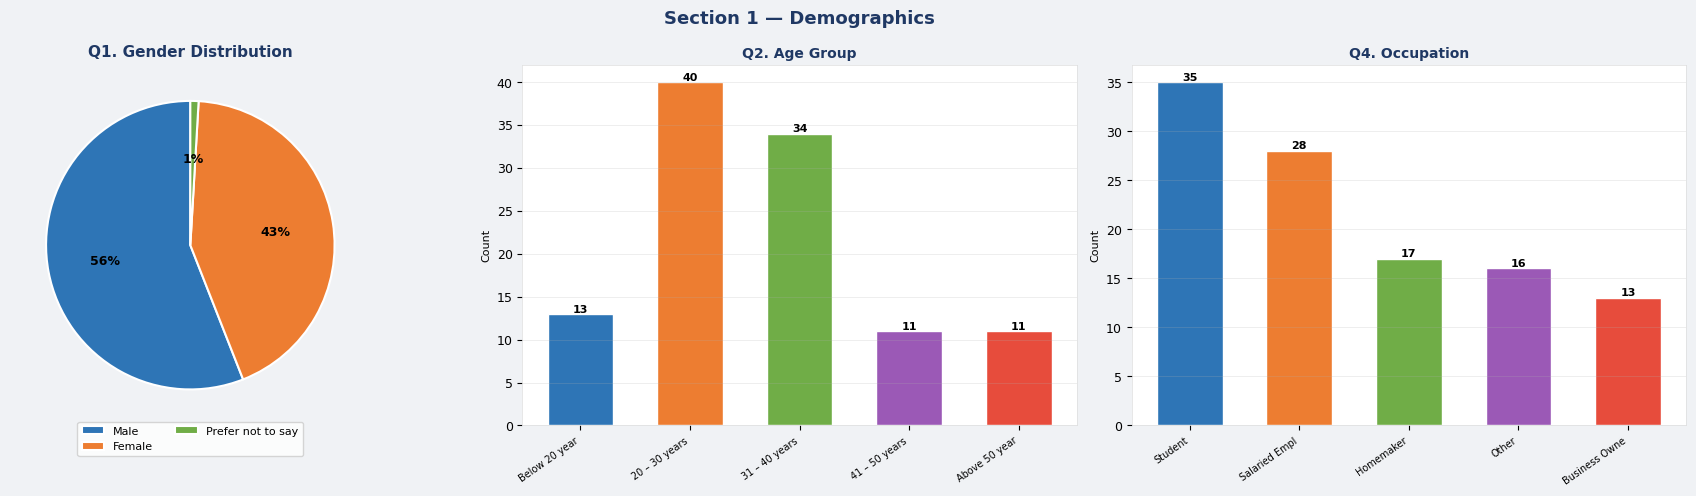

✅ Chart saved: chart_s1_demographics.png


In [12]:
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.patch.set_facecolor('#F0F2F5')
fig1.suptitle('Section 1 — Demographics', fontsize=13, fontweight='bold', color='#1F3864')

for ax in axes1:
    ax.set_facecolor('white')
    for sp in ax.spines.values(): sp.set_color('#DDDDDD'); sp.set_linewidth(0.5)

# Gender pie
vc = df[Q['gender']].value_counts()
_, _, autotexts = axes1[0].pie(vc.values, labels=None, colors=C[:len(vc)],
    autopct='%1.0f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts: at.set_fontsize(9); at.set_fontweight('bold')
axes1[0].legend(vc.index, loc='lower center', fontsize=8, bbox_to_anchor=(0.5,-0.1), ncol=2)
axes1[0].set_title('Q1. Gender Distribution', fontsize=11, fontweight='bold', color='#1F3864')

# Age bar
age_ord = ['Below 20 years','20 – 30 years','31 – 40 years','41 – 50 years','Above 50 years']
vbar(axes1[1], df[Q['age']], 'Q2. Age Group', ordered=age_ord)

# Occupation
vbar(axes1[2], df[Q['occ']], 'Q4. Occupation')

plt.tight_layout()
plt.savefig('chart_s1_demographics.png', dpi=150, bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print('✅ Chart saved: chart_s1_demographics.png')

## Step 9 — Shopping Behaviour Charts (Section 2)
Visit frequency, Spending, Preferred Day, Payment Method

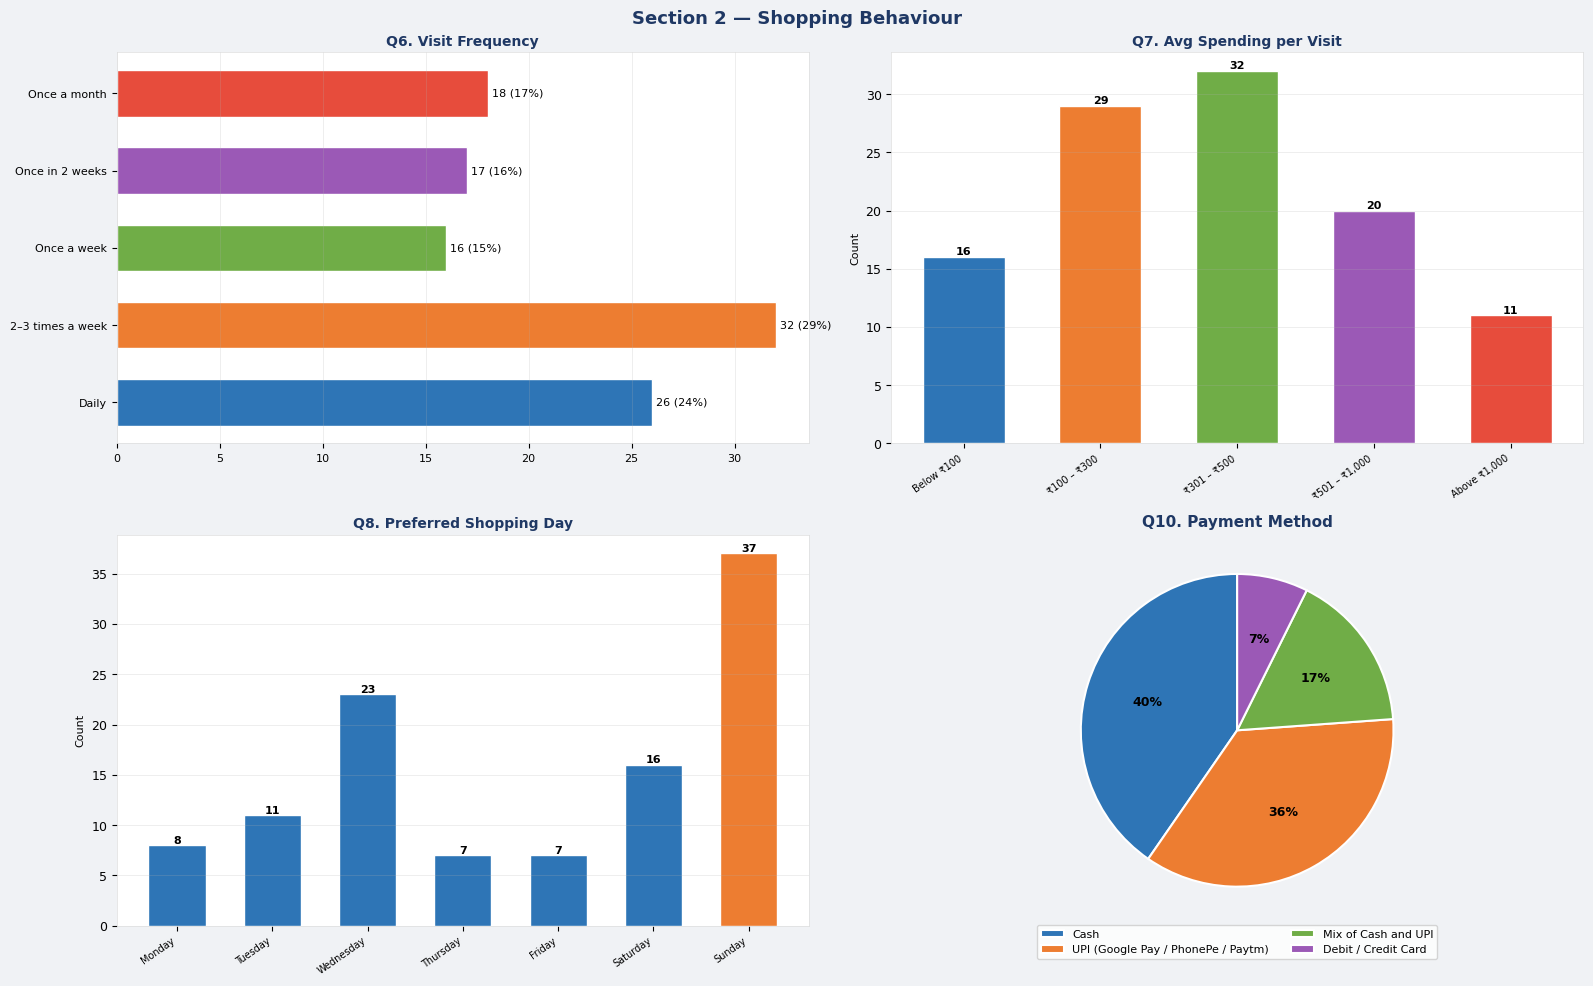

✅ Chart saved: chart_s2_behaviour.png


In [13]:
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))
fig2.patch.set_facecolor('#F0F2F5')
fig2.suptitle('Section 2 — Shopping Behaviour', fontsize=13, fontweight='bold', color='#1F3864')

for ax in axes2.flat:
    ax.set_facecolor('white')
    for sp in ax.spines.values(): sp.set_color('#DDDDDD'); sp.set_linewidth(0.5)

hbar(axes2[0,0], df[Q['freq']], 'Q6. Visit Frequency',
     ordered=['Daily','2–3 times a week','Once a week','Once in 2 weeks','Once a month'])
vbar(axes2[0,1], df[Q['spend']], 'Q7. Avg Spending per Visit',
     ordered=['Below ₹100','₹100 – ₹300','₹301 – ₹500','₹501 – ₹1,000','Above ₹1,000'])
vbar(axes2[1,0], df[Q['day']], 'Q8. Preferred Shopping Day',
     ordered=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
     bar_colors=['#2E75B6']*6+['#ED7D31'])

vc = df[Q['pay']].value_counts()
_, _, ats = axes2[1,1].pie(vc.values, labels=None, colors=C[:len(vc)],
    autopct='%1.0f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in ats: at.set_fontsize(9); at.set_fontweight('bold')
axes2[1,1].legend(vc.index, loc='lower center', fontsize=8, bbox_to_anchor=(0.5,-0.1), ncol=2)
axes2[1,1].set_title('Q10. Payment Method', fontsize=11, fontweight='bold', color='#1F3864')

plt.tight_layout()
plt.savefig('chart_s2_behaviour.png', dpi=150, bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print('✅ Chart saved: chart_s2_behaviour.png')

## Step 10 — Discount & Satisfaction Charts (Sections 4 & 5)

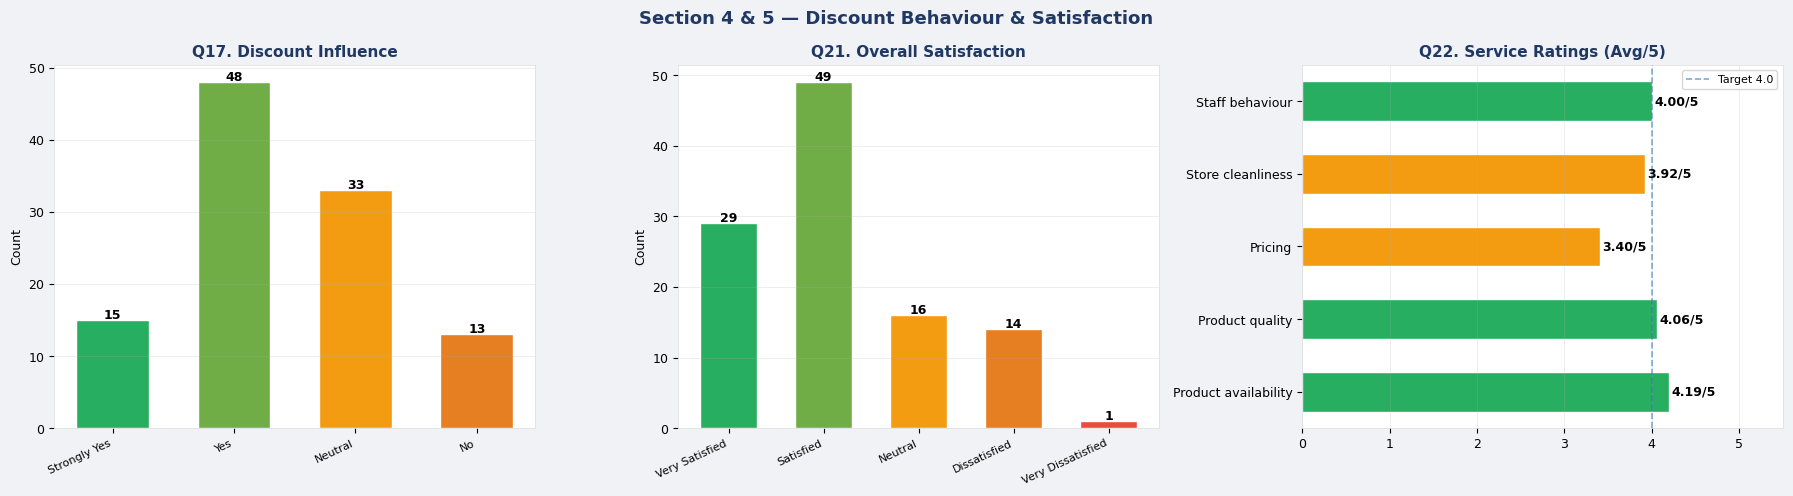

✅ Chart saved: chart_s4_discount_satisfaction.png


In [14]:
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
fig3.patch.set_facecolor('#F0F2F5')
fig3.suptitle('Section 4 & 5 — Discount Behaviour & Satisfaction', fontsize=13, fontweight='bold', color='#1F3864')

for ax in axes3:
    ax.set_facecolor('white')
    for sp in ax.spines.values(): sp.set_color('#DDDDDD'); sp.set_linewidth(0.5)

sat_clrs = ['#27AE60','#70AD47','#F39C12','#E67E22','#E74C3C']
disc_ord = ['Strongly Yes','Yes','Neutral','No','Strongly No']
vc = df[Q['disc_inf']].value_counts().reindex([o for o in disc_ord if o in df[Q['disc_inf']].values]).dropna()
bars = axes3[0].bar(range(len(vc)), vc.values, color=sat_clrs[:len(vc)], edgecolor='white', width=0.6)
for bar, val in zip(bars, vc.values):
    axes3[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                  f'{val}', ha='center', fontsize=9, fontweight='bold')
axes3[0].set_xticks(range(len(vc)))
axes3[0].set_xticklabels(vc.index, rotation=25, ha='right', fontsize=8)
axes3[0].set_title('Q17. Discount Influence', fontsize=11, fontweight='bold', color='#1F3864')
axes3[0].set_ylabel('Count'); axes3[0].grid(axis='y', alpha=0.3, lw=0.5)

sat_ord = ['Very Satisfied','Satisfied','Neutral','Dissatisfied','Very Dissatisfied']
vc2 = df[Q['sat']].value_counts().reindex([o for o in sat_ord if o in df[Q['sat']].values]).dropna()
bars = axes3[1].bar(range(len(vc2)), vc2.values, color=sat_clrs[:len(vc2)], edgecolor='white', width=0.6)
for bar, val in zip(bars, vc2.values):
    axes3[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                  f'{val}', ha='center', fontsize=9, fontweight='bold')
axes3[1].set_xticks(range(len(vc2)))
axes3[1].set_xticklabels(vc2.index, rotation=25, ha='right', fontsize=8)
axes3[1].set_title('Q21. Overall Satisfaction', fontsize=11, fontweight='bold', color='#1F3864')
axes3[1].set_ylabel('Count'); axes3[1].grid(axis='y', alpha=0.3, lw=0.5)

rvals = [df[Q[k]].mean() for k in rcols]
rclrs = ['#27AE60' if v>=4 else '#F39C12' if v>=3 else '#E74C3C' for v in rvals]
bars = axes3[2].barh(rlbls, rvals, color=rclrs, edgecolor='white', height=0.55)
for bar, val in zip(bars, rvals):
    axes3[2].text(val+0.03, bar.get_y()+bar.get_height()/2,
                  f'{val:.2f}/5', va='center', fontsize=9, fontweight='bold')
axes3[2].set_xlim(0, 5.5)
axes3[2].axvline(x=4, color='#2E75B6', lw=1.2, linestyle='--', alpha=0.6, label='Target 4.0')
axes3[2].set_title('Q22. Service Ratings (Avg/5)', fontsize=11, fontweight='bold', color='#1F3864')
axes3[2].legend(fontsize=8); axes3[2].grid(axis='x', alpha=0.3, lw=0.5)

plt.tight_layout()
plt.savefig('chart_s4_discount_satisfaction.png', dpi=150, bbox_inches='tight', facecolor='#F0F2F5')
plt.show()
print('✅ Chart saved: chart_s4_discount_satisfaction.png')

## Step 11 — Export Clean Data

In [15]:
df.to_csv('survey_clean_final.csv', index=False, encoding='utf-8-sig')
print('✅ Clean data exported: survey_clean_final.csv')
print(f'   Rows: {len(df)} | Columns: {len(df.columns)}')
print('\n✅ All survey analysis complete!')

✅ Clean data exported: survey_clean_final.csv
   Rows: 109 | Columns: 30

✅ All survey analysis complete!
